# Topic 8. Data Visualisation - Seaborn

Install seaborn

    - pip install seaborn
    - conda install seaborn


In [40]:
import seaborn as sns

## Many ways to customise the looks of the graphs
# 1. Set the context and style
sns.set_context("notebook")
#sns.set_style("whitegrid")

# 2. Set the theme directly

#sns.set_theme(context="notebook")

sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)
# can choose popular style like "darkgrid," "whitegrid," "dark," "white," etc.

# Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

In [41]:
%matplotlib inline

In [42]:
tips = sns.load_dataset('tips') # use the build-in-dataset tips

In [43]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [104]:
tips["tip_pct"] = tips["tip"] / tips["total_bill"]

/var/folders/9b/cftrg1jx1hg3brjq8_ppvrr80000gp/T/ipykernel_87445/4016659384.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'])
/var/folders/9b/cftrg1jx1hg3brjq8_ppvrr80000gp/T/ipykernel_87445/4016659384.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'],b

<Axes: xlabel='total_bill', ylabel='Density'>

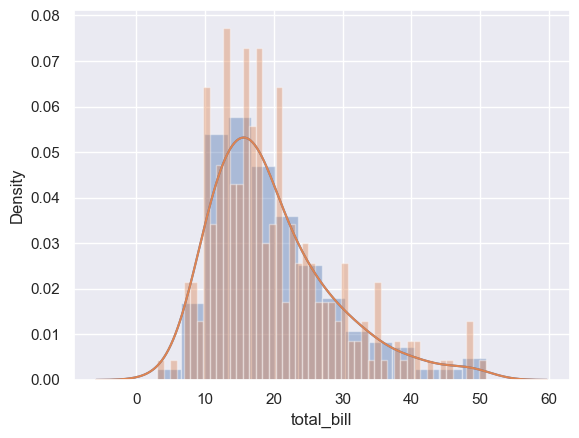

In [44]:
# univariate distribution plot
sns.distplot(tips['total_bill'])
# remove the kernel density fit
#sns.distplot(tips['total_bill'],kde=False)

sns.distplot(tips['total_bill'],bins=50)

<Axes: xlabel='tip_pct', ylabel='Count'>

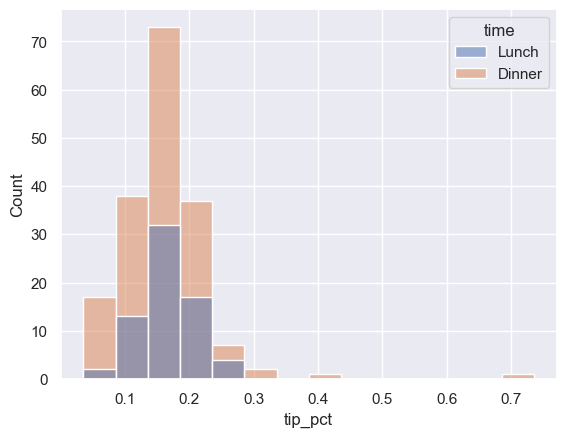

In [105]:
sns.histplot(data=tips, x="tip_pct", binwidth=0.05, hue="time")

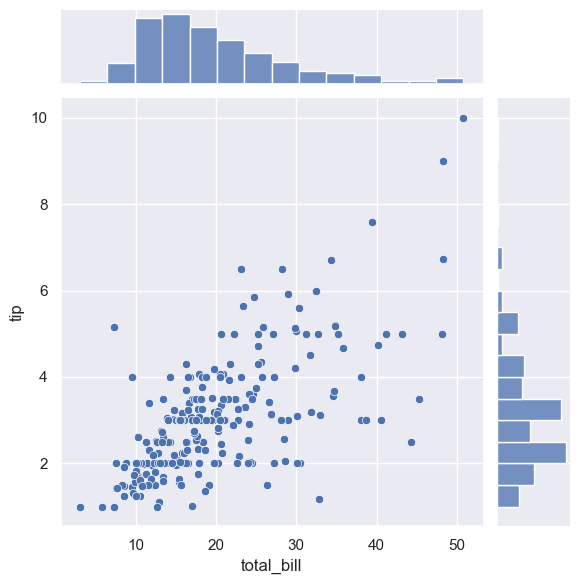

In [45]:
# two-variable plot
sns.jointplot(x='total_bill',y='tip',data=tips)

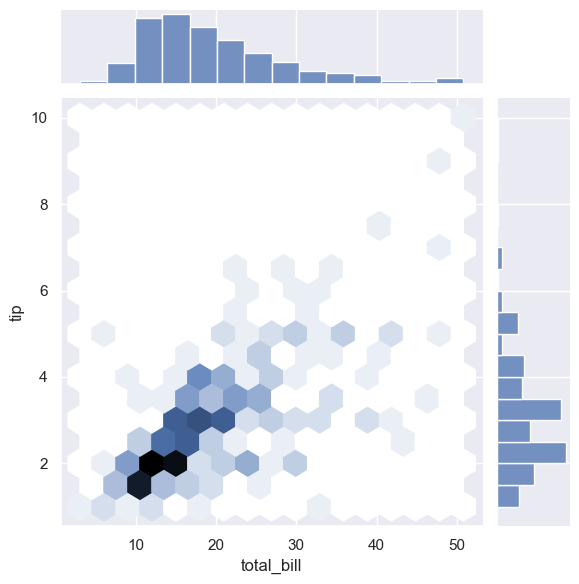

In [46]:
# two-variable plot
sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex')

# similar to scatter points, but inform intensity of data distribution. Dark mean more data in that point.

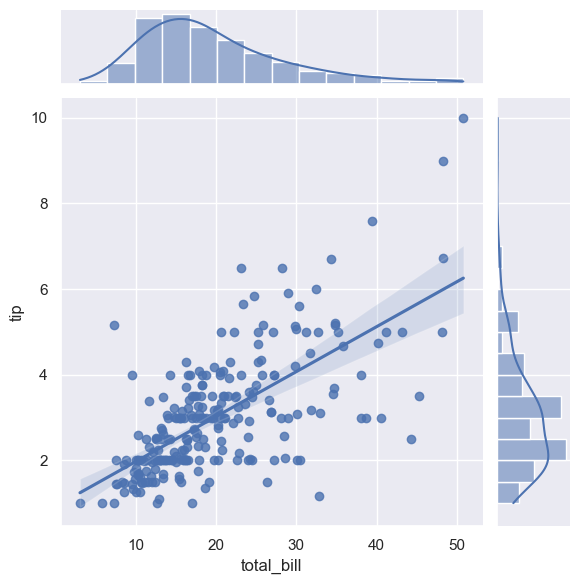

In [47]:
# two-variable plot
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg')
# linear fit to the scatter plot

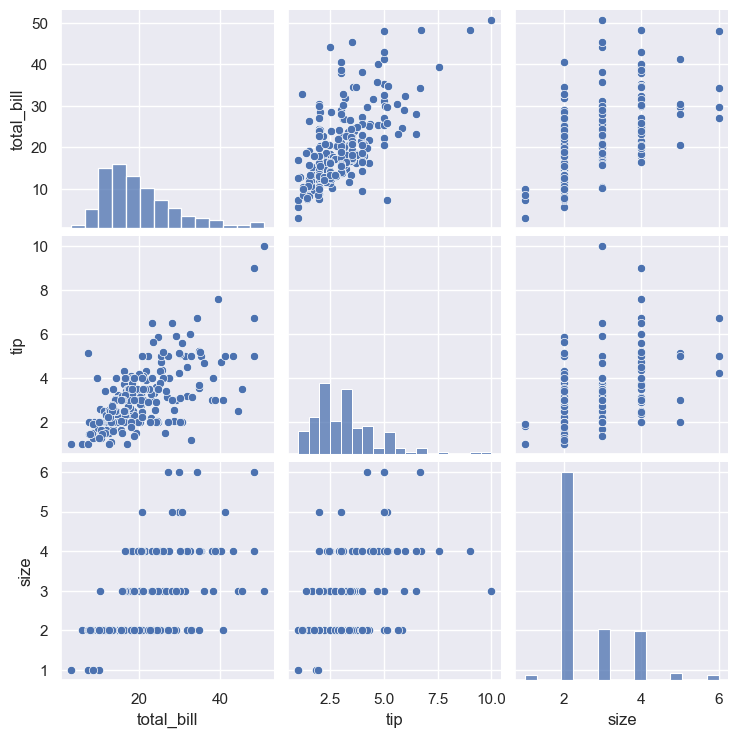

In [52]:
# do joinplot for all numeric columns in the dataset
sns.pairplot(tips)

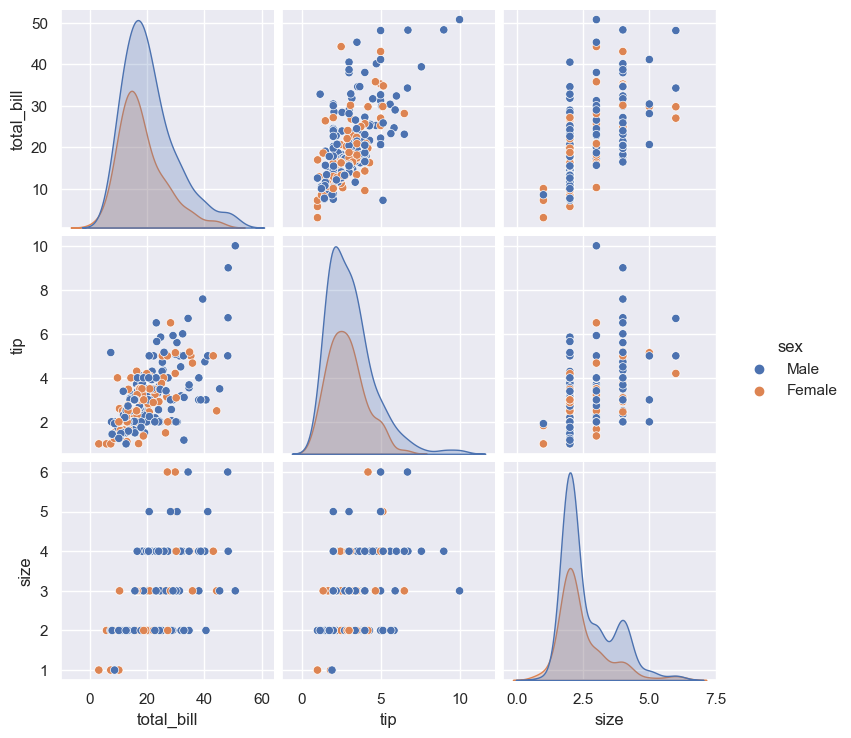

In [53]:
# do pairplot by categorical variable
sns.pairplot(tips, hue='sex')

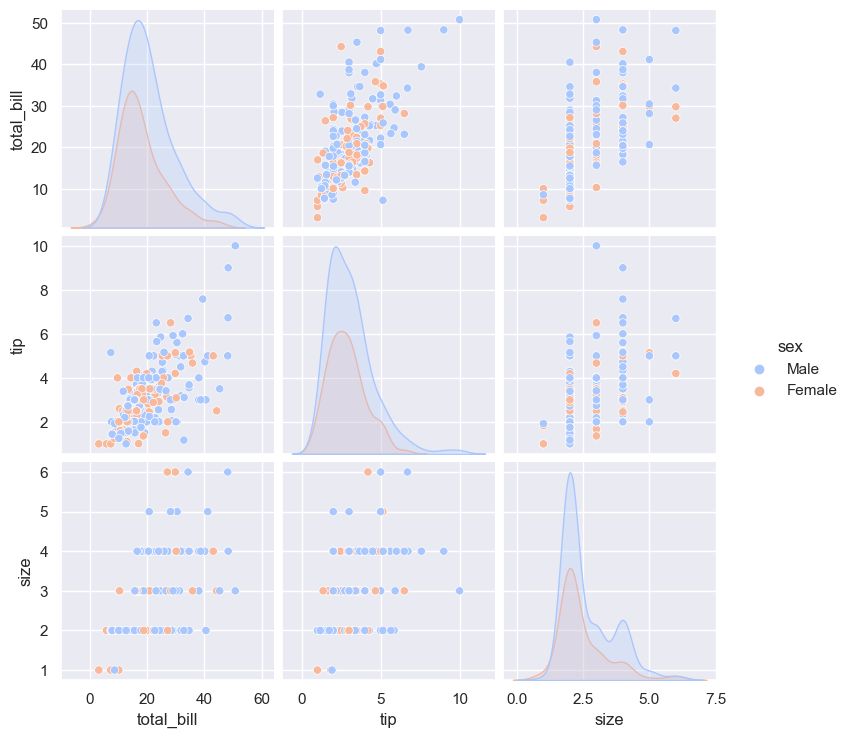

In [56]:
sns.pairplot(tips, hue='sex',palette='coolwarm')

<Axes: xlabel='total_bill'>

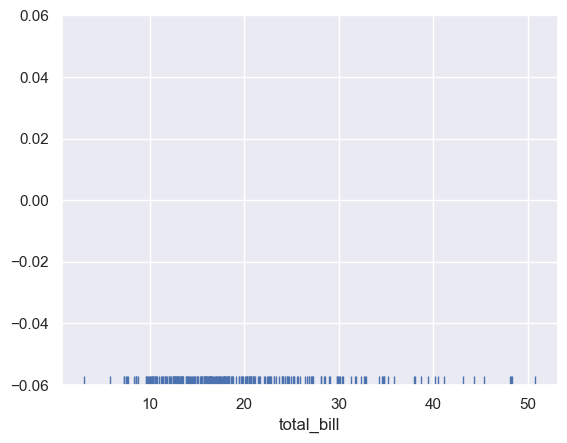

In [57]:
# rugplot draws the single dash line for every single data point assuming uniform distribution of each point
sns.rugplot(tips['total_bill'])

<Axes: xlabel='total_bill', ylabel='Count'>

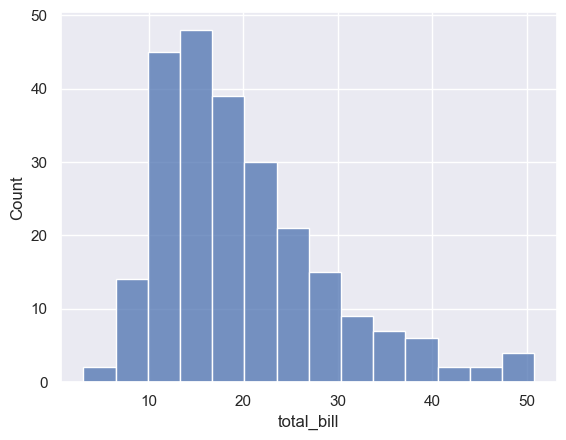

In [61]:
# distplot is phasing out, use more of histplot or displot
sns.histplot(tips['total_bill'],kde=False)

/var/folders/9b/cftrg1jx1hg3brjq8_ppvrr80000gp/T/ipykernel_87445/4271412032.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'])


<Axes: xlabel='total_bill', ylabel='Density'>

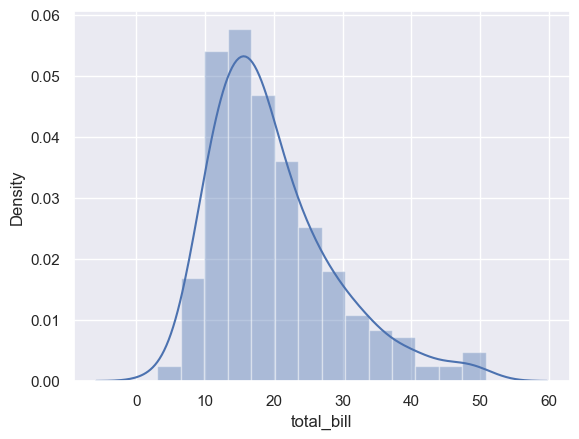

In [63]:
sns.distplot(tips['total_bill'])

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

In [73]:
import seaborn as sns
%matplotlib inline

In [74]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

<Axes: xlabel='sex', ylabel='total_bill'>

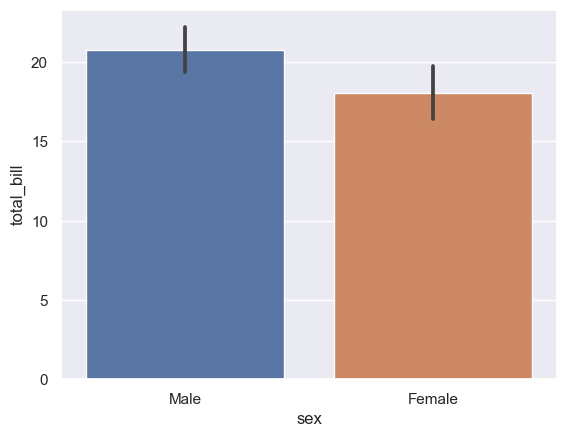

In [75]:
sns.barplot(x='sex',y='total_bill',data=tips)

<Axes: xlabel='day', ylabel='tip'>

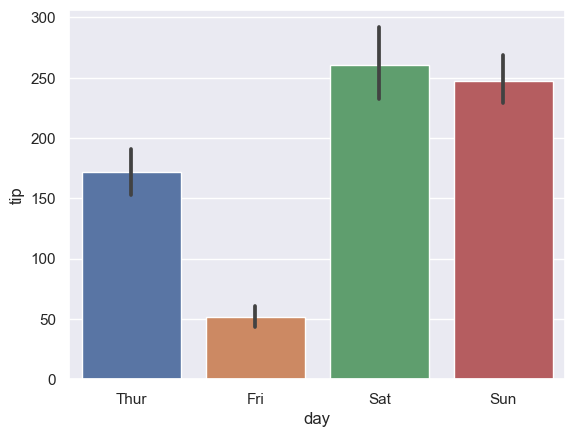

In [106]:
sns.barplot(data=tips, x="day", y="tip", estimator=np.sum)
# friday is low tip day

In [76]:
import numpy as np

You can change the estimator object to your own function, that converts a vector to a scalar:

<Axes: xlabel='sex', ylabel='total_bill'>

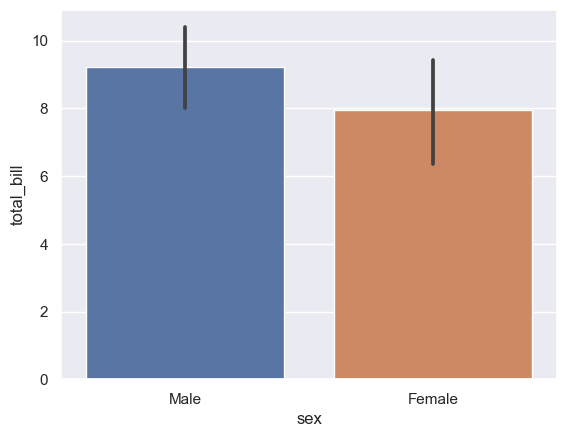

In [77]:
sns.barplot(x='sex',y='total_bill',data=tips,estimator=np.std)

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

<Axes: xlabel='sex', ylabel='count'>

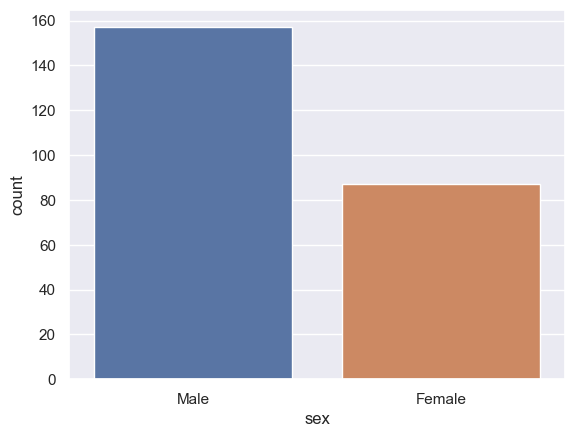

In [78]:
sns.countplot(x='sex',data=tips)

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

<Axes: xlabel='day', ylabel='total_bill'>

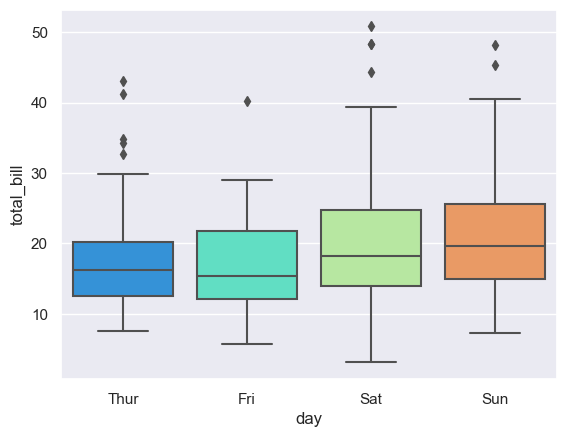

In [79]:
bill_by_day = sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow')
bill_by_day.set(xlabel="Day")
bill_by_day.set(ylabel="Total Bill")
bill_by_day.set(title="Total Bill By Day")

<Axes: >

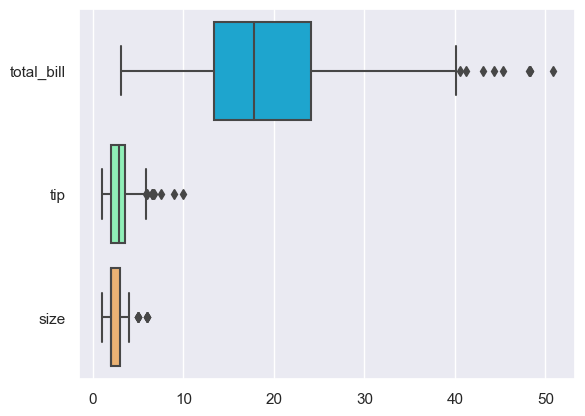

In [80]:
# Can do entire dataframe with orient='h'
sns.boxplot(data=tips,palette='rainbow',orient='h')

<Axes: xlabel='day', ylabel='total_bill'>

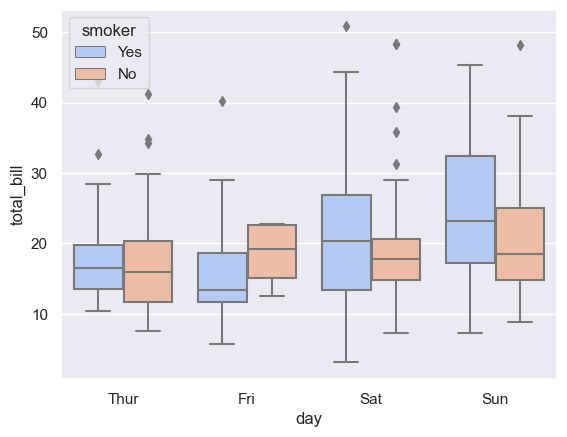

In [81]:
sns.boxplot(x="day", y="total_bill", hue="smoker",data=tips, palette="coolwarm")

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

<Axes: xlabel='day', ylabel='total_bill'>

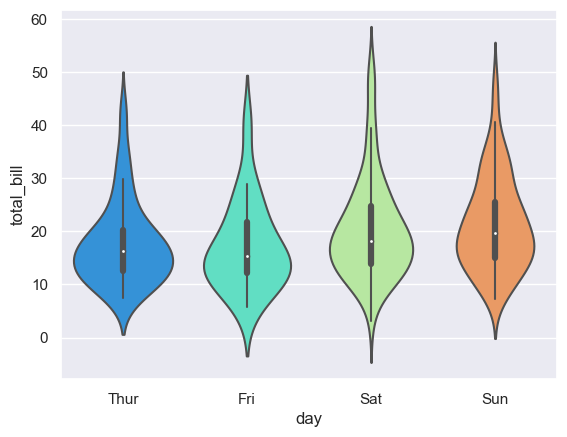

In [82]:
sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow')

<Axes: xlabel='day', ylabel='total_bill'>

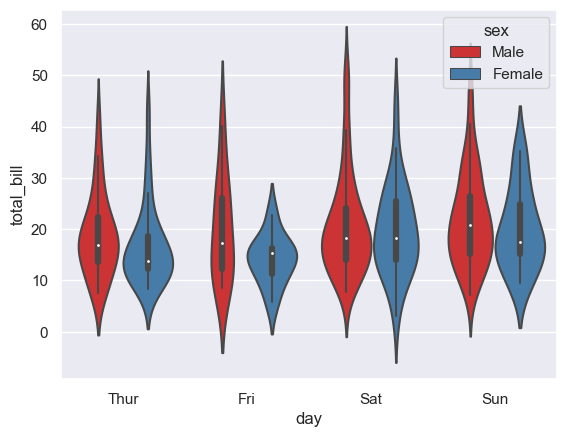

In [83]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',palette='Set1')

<Axes: xlabel='day', ylabel='total_bill'>

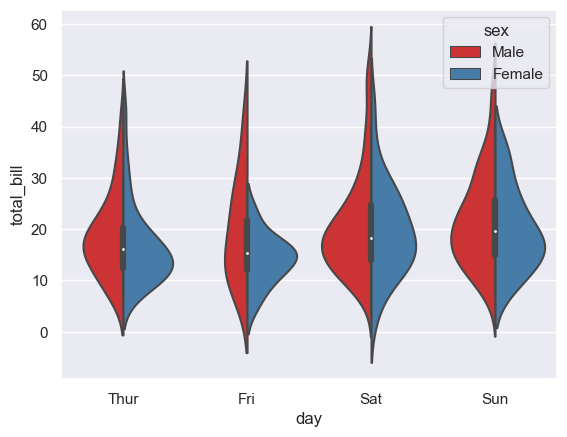

In [84]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',split=True,palette='Set1')

## stripplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.


<Axes: xlabel='day', ylabel='total_bill'>

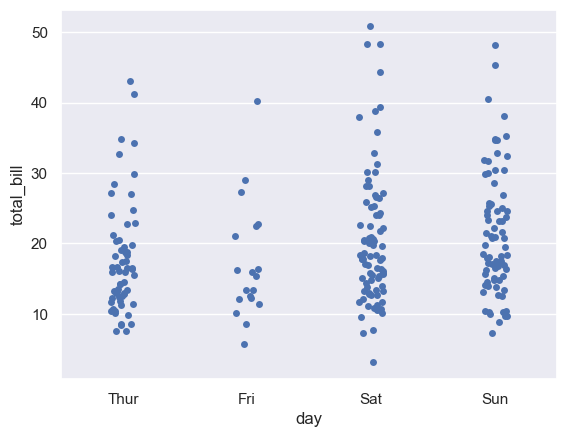

In [85]:
sns.stripplot(x="day", y="total_bill", data=tips)

<Axes: xlabel='day', ylabel='total_bill'>

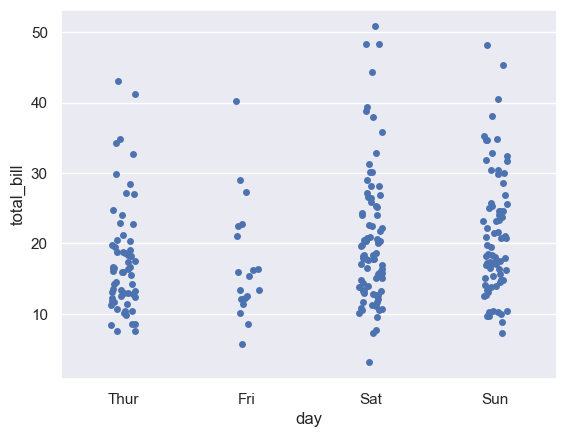

In [86]:
# the stright line strip is how to tell the distribution because they all stack on top of each other

# jitter allows to add some noise, so, we can better understand the distribution

sns.stripplot(x="day", y="total_bill", data=tips,jitter=True)

<Axes: xlabel='day', ylabel='total_bill'>

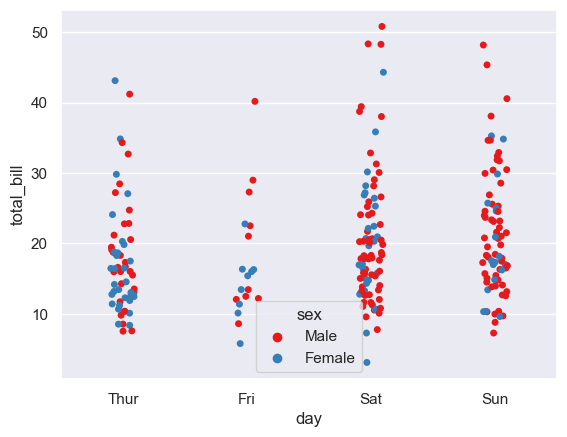

In [87]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1')

AttributeError: PathCollection.set() got an unexpected keyword argument 'split'

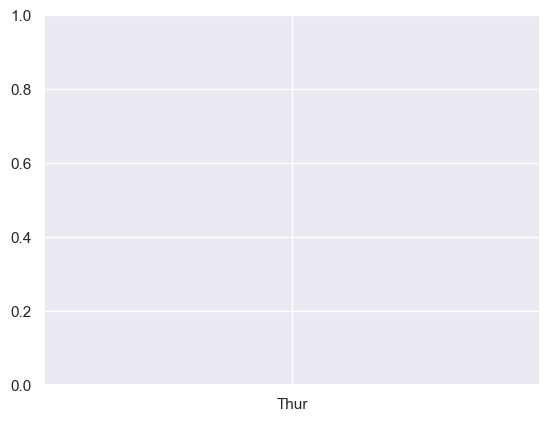

In [88]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1',split=True)

# Regression Plots

To have a simple start, we will only cover the **lmplot()** function for now.

**lmplot** allows you to display linear models, but it also conveniently allows you to split up those plots based off of features, as well as coloring the hue based off of features.

Let's explore how this works:

In [90]:
import seaborn as sns
%matplotlib inline

In [91]:
tips = sns.load_dataset('tips')

In [92]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## lmplot()

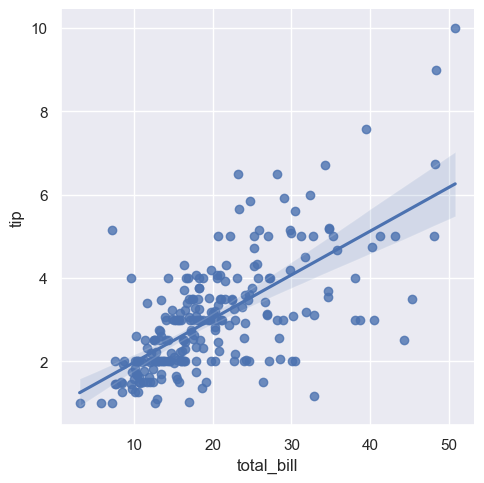

In [93]:
sns.lmplot(x='total_bill',y='tip',data=tips)

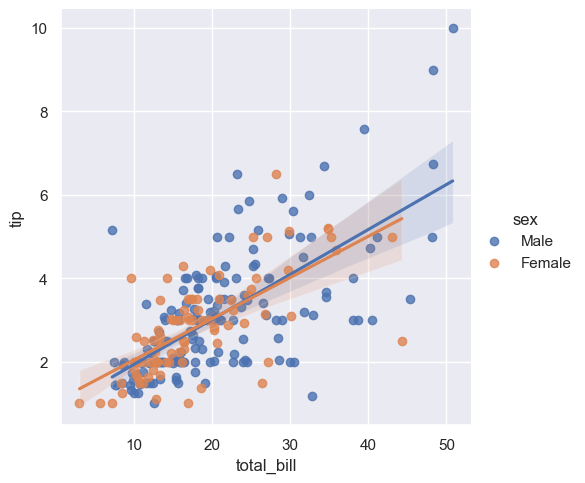

In [94]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex')

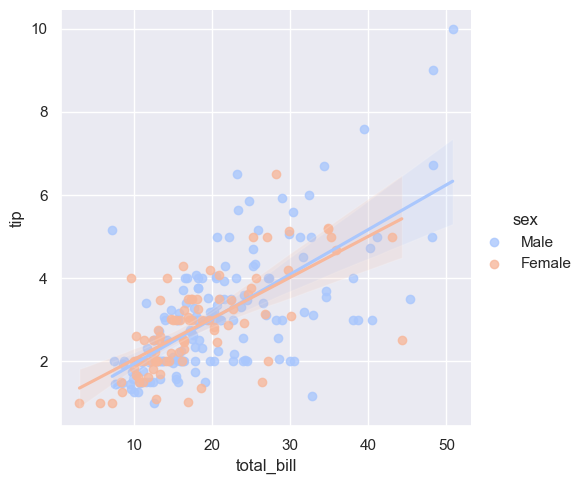

In [95]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex',palette='coolwarm')

### Working with Markers

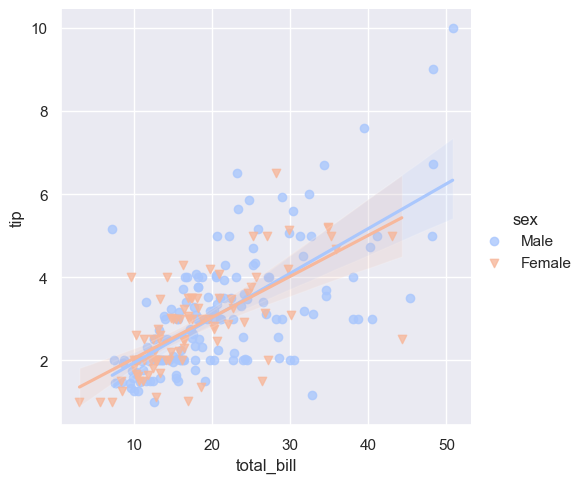

In [96]:
# http://matplotlib.org/api/markers_api.html
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex',palette='coolwarm',
           markers=['o','v'])

## Using a Grid

We can add more variable separation through columns and rows with the use of a grid. Just indicate this with the col or row arguments:

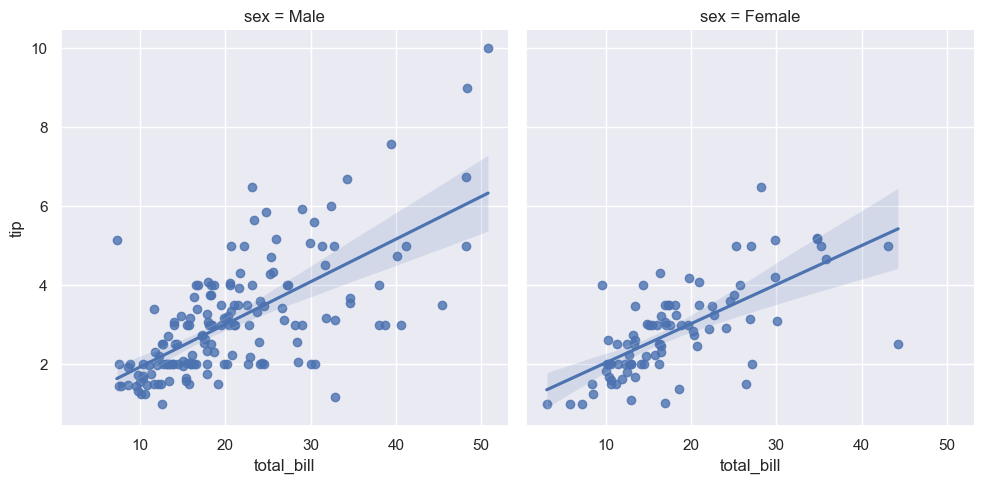

In [97]:
# col='sex' is like by sex 
sns.lmplot(x='total_bill',y='tip',data=tips,col='sex')

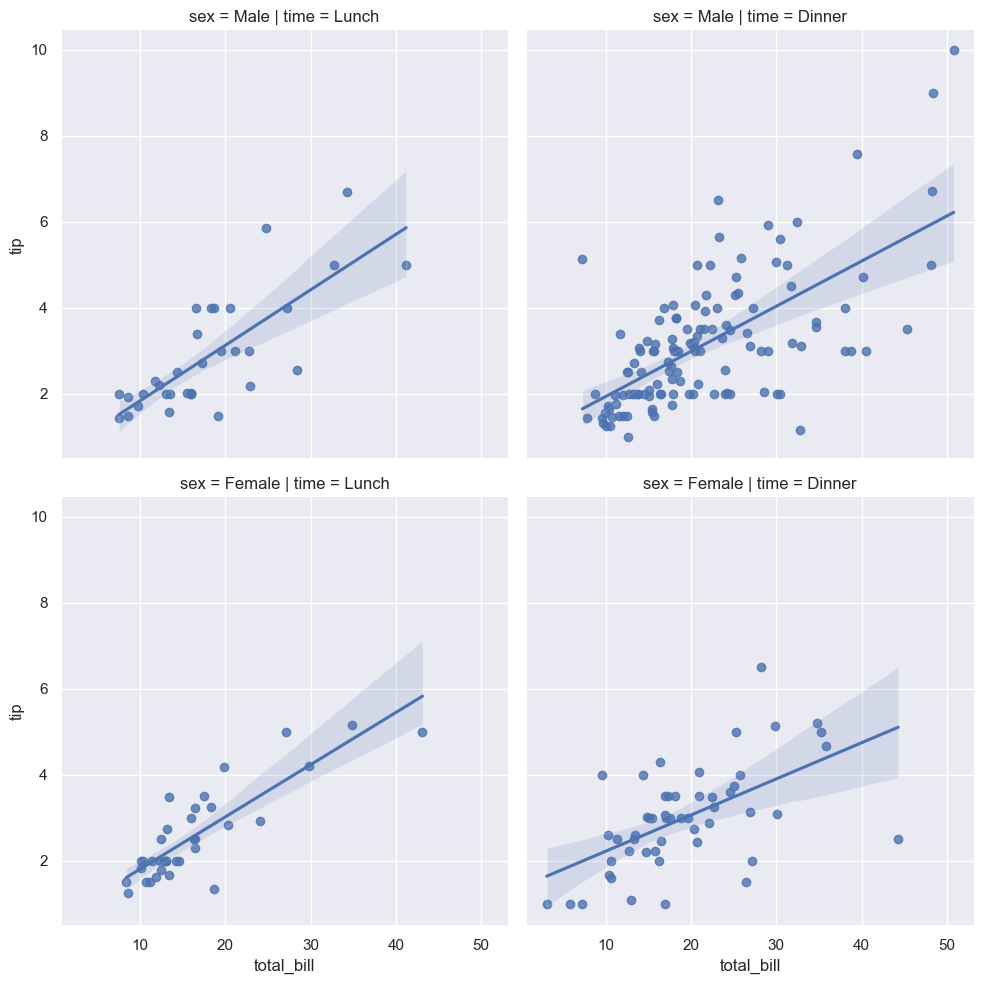

In [98]:
sns.lmplot(x="total_bill", y="tip", row="sex", col="time",data=tips)

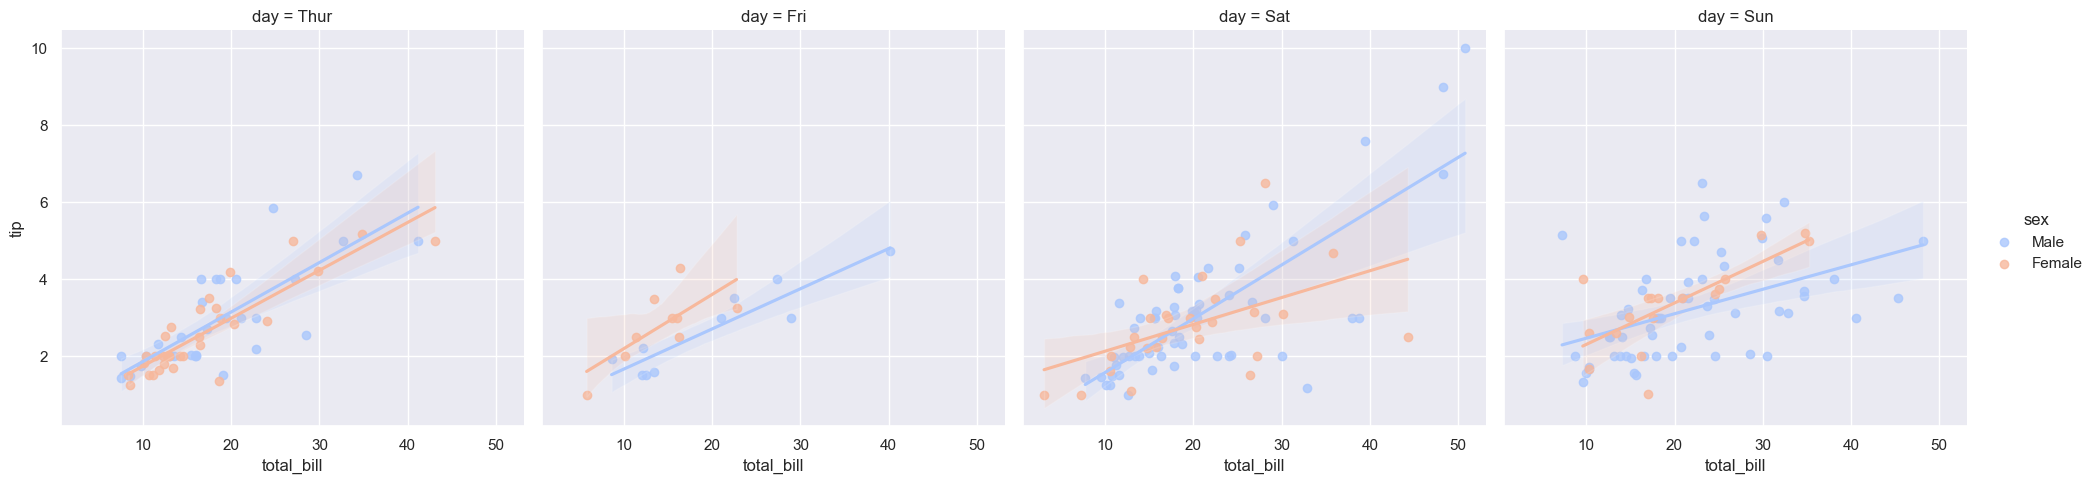

In [99]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm')

## Aspect and Size

Seaborn figures can have their size and aspect ratio adjusted with the **size** and **aspect** parameters:

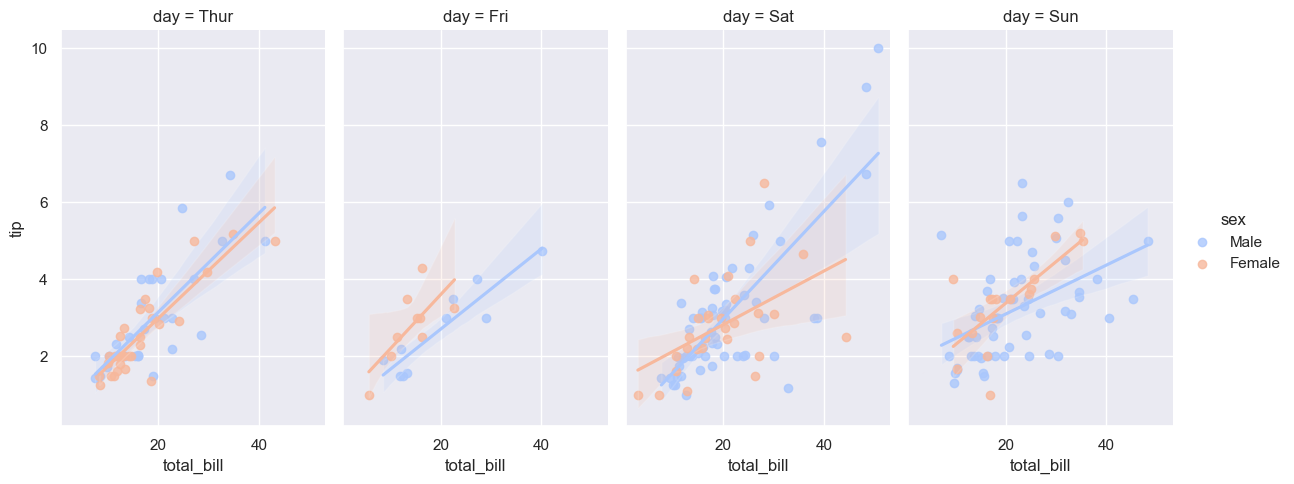

In [101]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm',
          aspect=0.6)
# aspect = 0.6 means width is 0.6 of height for each facet.

### Impact of table size and day on the tip 

Sometimes we want to understand how two variables play together to determine output. 
For example, how do the day of the week and the table size impact the tip percentage?

To draw the next chart we will combine the pivot function of pandas to pre-process the information and then draw a heatmap chart.

<Axes: xlabel='size', ylabel='day'>

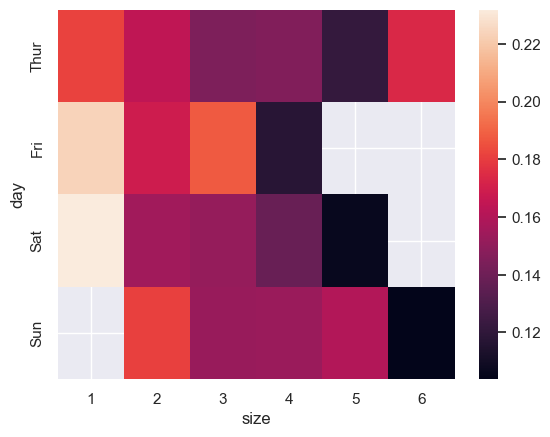

In [107]:
pivot = tips.pivot_table(
    index=["day"],
    columns=["size"],
    values="tip_percentage",
    aggfunc=np.average)
sns.heatmap(pivot)